<a href="https://colab.research.google.com/github/espindolaleticia/cp2_sers/blob/main/AULA_07_Regress%C3%A3o_Linear_com_Dados_de_Energia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Checkpoint 2 – Regressão Linear e Estabilidade da Rede Elétrica

Esta atividade faz parte do **Checkpoint 2**. O objetivo é construir e comparar dois modelos de Regressão Linear para prever o valor numérico da coluna `stab`, relacionada à estabilidade da rede elétrica.

Ao finalizar, salve este notebook no formato `.ipynb` e faça o upload no **repositório GitHub da atividade criado anteriormente**. Mantenha todas as células executadas, os resultados visíveis e as respostas preenchidas.

## 1. Importação das bibliotecas

Importe as bibliotecas necessárias para manipulação e visualização dos dados, separação entre treino e teste, criação do modelo de Regressão Linear e cálculo das métricas R², MAE e MSE.

In [1]:
# Importe aqui as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
#Algoritmo de regrassão linear
from sklearn.linear_model import LinearRegression
#Métricas para regressão
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## 2. Carregamento e análise inicial do dataset

Carregue o arquivo CSV do conjunto **Electrical Grid Stability** em um DataFrame chamado `df`. Depois:

- visualize as primeiras linhas;
- verifique a quantidade de linhas e colunas;
- apresente os nomes e os tipos das colunas;
- verifique se existem valores ausentes;
- apresente as estatísticas descritivas das variáveis numéricas.

In [2]:
# Carregue o dataset e realize a análise inicial
dados = pd.read_csv ('https://raw.githubusercontent.com/espindolaleticia/cp2_sers/refs/heads/main/Data_for_UCI_named.csv')
dados.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


### Registro da análise inicial

**Quantidade de linhas:**  
**Quantidade de colunas:**  
**Existem valores ausentes?**  
**Observações importantes sobre o dataset:**  

In [4]:
#Quantidade de linhas e colunas
dados.shape
print(f'Linhas: {dados.shape[0]}')
print(f'Colunas: {dados.shape[1]}')

#Valores ausentes
print(f'Existem valores ausentes? {dados.isnull().values.any()}')

Linhas: 10000
Colunas: 14
Existem valores ausentes? False


Observações importantes sobre o dataset: Esse dataset tem 10000 linhas, 14 colunas e nenhum valor ausente

## 3. Definição da variável target

A variável que os modelos deverão prever é a coluna `stab`. Crie a variável `y` com essa coluna e apresente seus primeiros valores.

In [5]:
# Crie a variável y usando a coluna stab
# y = ...
y = dados['stab']
y.head()

,stab
0,0.055347
1,-0.005957
2,0.003471
3,0.028871
4,0.049860


## 4. Matriz de correlação

Calcule a matriz de correlação das variáveis numéricas e crie um mapa de calor (*heatmap*). Em seguida, identifique as **cinco variáveis com maior correlação absoluta com `stab`**, sem considerar a própria coluna `stab`.

Considere também correlações negativas: quanto mais próximo de +1 ou -1, maior é a intensidade da relação linear.

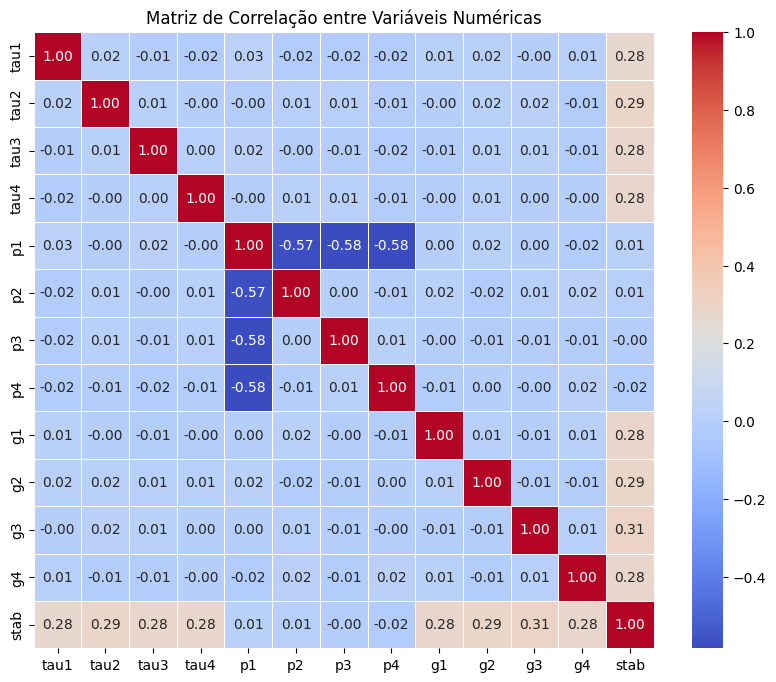

In [12]:
# Calcule e visualize a matriz de correlação
dados_numericos = dados.select_dtypes(include=np.number)
correlacoes = dados_numericos.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlacoes, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlação entre Variáveis Numéricas')
plt.show()

## 5. Apoio do Gemini para seleção e visualização das variáveis

Depois de criar a matriz de correlação, use o Gemini no Google Colab com o prompt abaixo. Analise o código sugerido antes de executá-lo e faça os ajustes necessários.

> Tenho um DataFrame Pandas chamado `df` com dados do Electrical Grid Stability. A variável target é a coluna `stab`. Gere um código Python que: (1) calcule a correlação das variáveis numéricas com `stab`; (2) desconsidere a própria coluna `stab`; (3) use o valor absoluto das correlações para identificar as cinco variáveis com maior correlação com `stab`; (4) apresente os nomes das cinco variáveis e os valores originais de correlação, preservando os sinais positivo ou negativo; (5) armazene os nomes dessas variáveis em uma lista chamada `cinco_variaveis`; e (6) crie cinco gráficos de dispersão, um para cada variável selecionada, usando a variável no eixo X e `stab` no eixo Y. Utilize Pandas, Matplotlib e Seaborn. O DataFrame `df` já está carregado.

As cinco variáveis com maior correlação absoluta com 'stab' são:
- g3: 0.3082
- g2: 0.2936
- tau2: 0.2910
- g1: 0.2828
- tau3: 0.2807


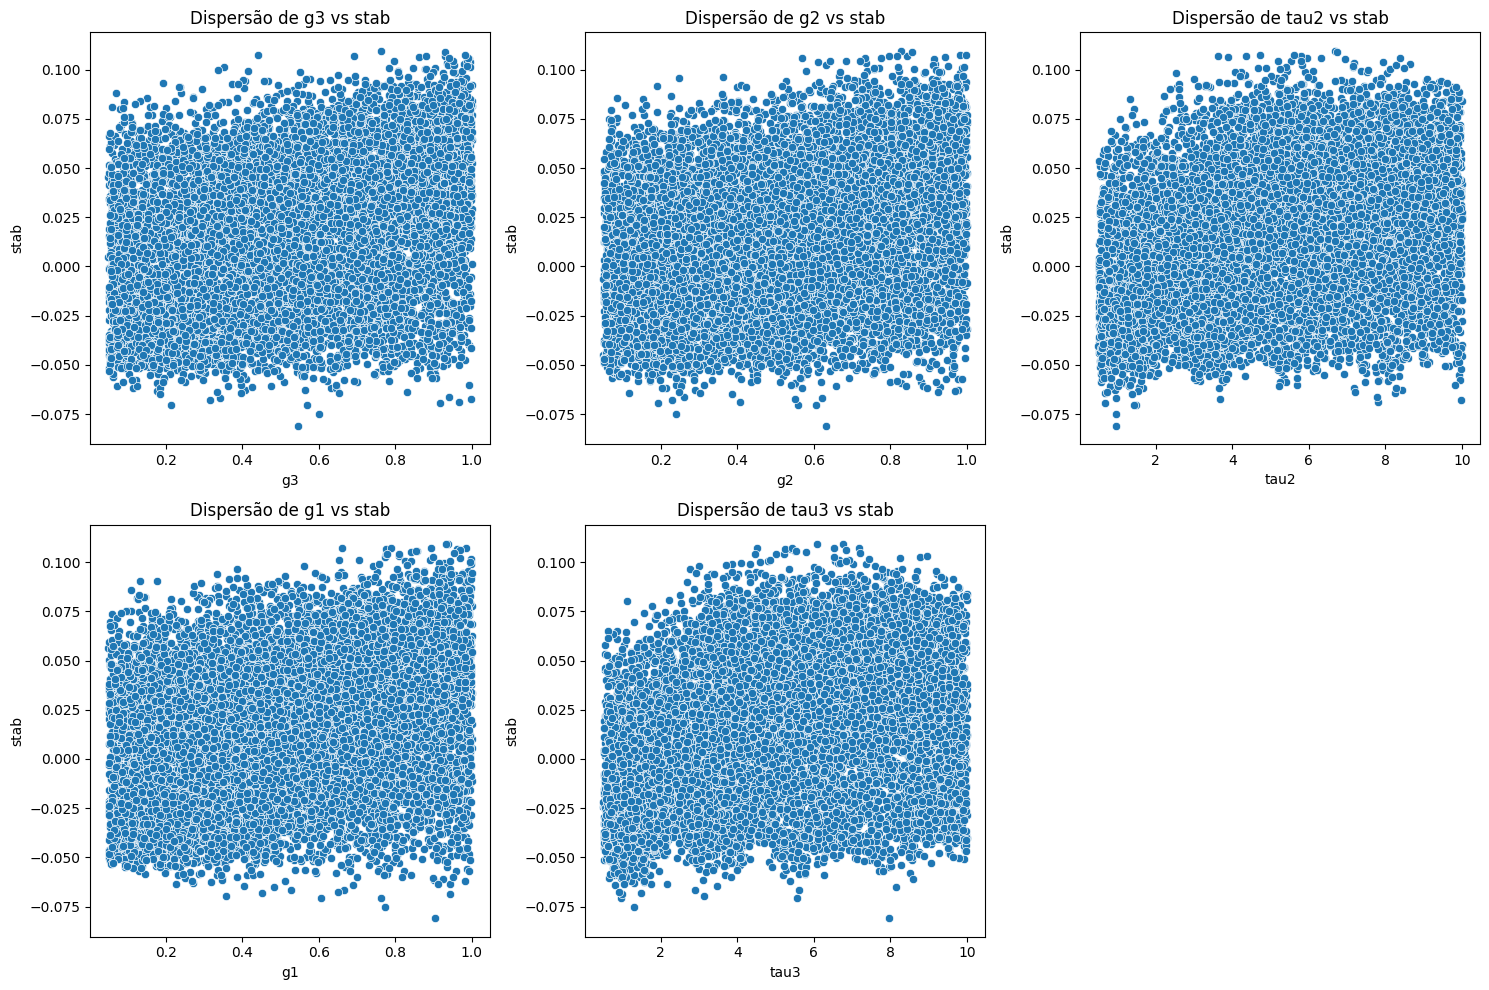

In [13]:
# (1) Calcule a correlação das variáveis numéricas com 'stab'
correlacoes_com_stab = dados_numericos.corr()['stab']

# (2) Desconsidere a própria coluna 'stab'
correlacoes_com_stab = correlacoes_com_stab.drop('stab')

# (3) Use o valor absoluto das correlações para identificar as cinco variáveis com maior correlação com 'stab'
top_5_correlacoes_abs = correlacoes_com_stab.abs().sort_values(ascending=False).head(5)

# (4) Apresente os nomes das cinco variáveis e os valores originais de correlação
print("As cinco variáveis com maior correlação absoluta com 'stab' são:")
for var_name in top_5_correlacoes_abs.index:
    print(f"- {var_name}: {correlacoes_com_stab[var_name]:.4f}")

# (5) Armazene os nomes dessas variáveis em uma lista chamada cinco_variaveis
cinco_variaveis = top_5_correlacoes_abs.index.tolist()

# (6) Crie cinco gráficos de dispersão
plt.figure(figsize=(15, 10))
for i, col in enumerate(cinco_variaveis):
    plt.subplot(2, 3, i + 1) # Arrange plots in a 2x3 grid
    sns.scatterplot(x=dados[col], y=dados['stab'])
    plt.title(f'Dispersão de {col} vs stab')
    plt.xlabel(col)
    plt.ylabel('stab')
plt.tight_layout()
plt.show()

### Variáveis selecionadas

| Posição | Variável | Correlação original com `stab` |
|---:|---|---:|
| 1 | g3 | 0.3082 |
| 2 | g2 | 0.2936 |
| 3 | tau2 | 0.2910 |
| 4 | g1 | 0.2828 |
| 5 | tau3 | 0.2807 |

**Qual variável apresentou a maior correlação absoluta com `stab`?**  
Resposta: A variável **g3** apresentou a maior correlação absoluta com `stab`, com um valor de 0.3082.

**O que os gráficos de dispersão indicam sobre as relações entre essas variáveis e `stab`?**  
Resposta: Os gráficos de dispersão indicam que, para as cinco variáveis selecionadas, há uma tendência de relação linear positiva com `stab`. Embora as correlações não sejam extremamente fortes, os pontos nos gráficos de dispersão mostram uma dispersão que sugere que, à medida que os valores dessas variáveis aumentam, os valores de `stab` também tendem a aumentar. No entanto, a relação não é perfeita e há bastante variabilidade nos dados, o que é esperado para correlações na faixa de 0.28 a 0.31. Não há relações curvilíneas ou padrões não lineares óbvios, apenas uma dispersão geral que acompanha a tendência positiva da correlação.

# Modelo 1 – Cinco maiores correlações

Crie o DataFrame `X` utilizando somente as cinco variáveis selecionadas a partir da matriz de correlação. A variável `y` deve continuar sendo a coluna `stab`.

In [14]:
# Crie X com as cinco variáveis selecionadas
# X = ...

# Mostre as primeiras linhas de X e y
X = dados[cinco_variaveis]
X.head()


,g3,g2,tau2,g1,tau3
0,0.887445,0.859578,3.079885,0.650456,8.381025
1,0.562139,0.862414,4.902524,0.413441,3.047541
2,0.839444,0.766689,8.848428,0.163041,3.046479
3,0.929381,0.976744,7.669600,0.446209,4.486641
4,0.656947,0.455450,7.608772,0.797110,4.943759


## 6. Separação entre treino e teste

Separe `X` e `y` utilizando 80% dos dados para treinamento e 20% para teste, com `random_state=42`. Use os nomes `X_treino`, `X_teste`, `y_treino` e `y_teste`. Apresente a quantidade de registros em cada conjunto.

In [16]:
# Separe os dados de treino e teste do Modelo 1
x  = dados[cinco_variaveis]
y = dados['stab']
X_treino, X_teste, y_treino, y_teste = train_test_split(x, y, test_size=0.2, random_state=42)
print(f'Quantidade de registros em X_treino: {X_treino.shape[0]}')
print(f'Quantidade de registros em X_teste: {X_teste.shape[0]}')
print(f'Quantidade de registros em y_treino: {y_treino.shape[0]}')
print(f'Quantidade de registros em y_teste: {y_teste.shape[0]}')

Quantidade de registros em X_treino: 8000
Quantidade de registros em X_teste: 2000
Quantidade de registros em y_treino: 8000
Quantidade de registros em y_teste: 2000


## 7. Treinamento e previsões do Modelo 1

Crie um modelo de Regressão Linear chamado obrigatoriamente `modeloLR`. Treine o modelo e gere as previsões do conjunto de teste em uma variável chamada `y_previsao_1`.

In [20]:
# Crie e treine modeloLR
modeloLR = LinearRegression()
modeloLR.fit(X_treino, y_treino)

# Gere y_previsao_1
y_previsao_1 = modeloLR.predict(X_teste)

## 8. Métricas do Modelo 1

Calcule R², MAE e MSE. Armazene os resultados nas variáveis `r2_modelo_1`, `mae_modelo_1` e `mse_modelo_1`. Esses valores serão usados na comparação final.

In [26]:
# Calcule e apresente as três métricas do Modelo 1
r2_modelo_1 = r2_score(y_teste, y_previsao_1)
mae_modelo_1 = mean_absolute_error(y_teste, y_previsao_1)
mse_modelo_1 = mean_squared_error(y_teste, y_previsao_1)
print(f'R² do Modelo 1: {r2_modelo_1:.4f}')
print(f'MAE do Modelo 1: {mae_modelo_1:.4f}')
print(f'MSE do Modelo 1: {mse_modelo_1:.4f}')

R² do Modelo 1: 0.4018
MAE do Modelo 1: 0.0233
MSE do Modelo 1: 0.0008


# Modelo 2 – Variáveis `tau` e `g`

Crie um novo DataFrame chamado `X_tau_g` contendo todas as colunas cujos nomes começam com `tau` ou `g`. Liste as colunas selecionadas para conferir o resultado. A variável target permanece `y = df['stab']`.

In [27]:
# Selecione todas as colunas iniciadas por tau ou g
# X_tau_g = ...

# Liste as colunas selecionadas
X_tau_g = dados.filter(regex=r'^(tau|g)')
X_tau_g.columns
print(X_tau_g.columns)


Index(['tau1', 'tau2', 'tau3', 'tau4', 'g1', 'g2', 'g3', 'g4'], dtype='object')


## 9. Separação entre treino e teste do Modelo 2

Separe `X_tau_g` e `y` usando novamente 80% para treino, 20% para teste e `random_state=42`. Use os nomes `X2_treino`, `X2_teste`, `y2_treino` e `y2_teste`.

Manter o mesmo `random_state` e a mesma proporção é importante para comparar os modelos sobre os mesmos registros de teste.

In [28]:
# Separe os dados de treino e teste do Modelo 2

# Confirme se y_teste e y2_teste possuem os mesmos índices

X_tau_g = dados.filter(regex=r'^(tau|g)')
y = dados['stab']
X2_treino, X2_teste, y2_treino, y2_teste = train_test_split(X_tau_g, y, test_size=0.2, random_state=42)
print(f'Quantidade de registros em X2_treino: {X2_treino.shape[0]}')
print(f'Quantidade de registros em X2_teste: {X2_teste.shape[0]}')
print(f'Quantidade de registros em y2_treino: {y2_treino.shape[0]}')
print(f'Quantidade de registros em y2_teste: {y2_teste.shape[0]}')

#conferir se os índices são os mesmos
print(f'Os índices de y_teste e y2_teste são os mesmos? {y_teste.index.equals(y2_teste.index)}')

Quantidade de registros em X2_treino: 8000
Quantidade de registros em X2_teste: 2000
Quantidade de registros em y2_treino: 8000
Quantidade de registros em y2_teste: 2000
Os índices de y_teste e y2_teste são os mesmos? True


## 10. Treinamento, previsões e métricas do Modelo 2

Crie um segundo modelo de Regressão Linear chamado `modeloLR_tau_g`. Treine-o, gere as previsões em `y_previsao_2` e armazene as métricas em `r2_modelo_2`, `mae_modelo_2` e `mse_modelo_2`.

In [29]:
# Crie e treine modeloLR_tau_g

# Gere y_previsao_2

# Calcule e apresente as três métricas do Modelo 2

modeloLR_tau_g = LinearRegression()
modeloLR_tau_g.fit(X2_treino, y2_treino)
y_previsao_2 = modeloLR_tau_g.predict(X2_teste)
r2_modelo_2 = r2_score(y2_teste, y_previsao_2)
mae_modelo_2 = mean_absolute_error(y2_teste, y_previsao_2)
mse_modelo_2 = mean_squared_error(y2_teste, y_previsao_2)

print(f'R² do Modelo 2: {r2_modelo_2:.4f}')
print(f'MAE do Modelo 2: {mae_modelo_2:.4f}')
print(f'MSE do Modelo 2: {mse_modelo_2:.4f}')


R² do Modelo 2: 0.6452
MAE do Modelo 2: 0.0176
MSE do Modelo 2: 0.0005


# Comparação das métricas dos dois modelos

As métricas devem ser analisadas **comparativamente**. Crie um único DataFrame chamado `comparacao_modelos` com uma linha para cada modelo e as colunas `Modelo`, `Variáveis utilizadas`, `R²`, `MAE` e `MSE`.

Na comparação:

- um **R² maior** indica que o modelo explica uma parcela maior da variação de `stab`;
- um **MAE menor** indica menor erro absoluto médio;
- um **MSE menor** indica menor erro quadrático médio e penaliza mais intensamente os erros maiores.

Não interprete as métricas de forma isolada: compare os valores obtidos pelos dois modelos.

In [30]:
# Crie e exiba o DataFrame comparacao_modelos
comparacao_modelos = pd.DataFrame({
    'Modelo': ['Modelo 1', 'Modelo 2'],
    'Variáveis utilizadas': ['Cinco variáveis selecionadas', 'Todas as variáveis tau e g'],
    'R²': [r2_modelo_1, r2_modelo_2],
    'MAE': [mae_modelo_1, mae_modelo_2],
    'MSE': [mse_modelo_1, mse_modelo_2]
})

comparacao_modelos

,Modelo,Variáveis utilizadas,R²,MAE,MSE
0,Modelo 1,Cinco variáveis selecionadas,0.401770,0.023310,0.000811
1,Modelo 2,Todas as variáveis tau e g,0.645229,0.017553,0.000481


## Visualização comparativa

Crie três gráficos de barras lado a lado ou em uma mesma figura:

1. R² dos dois modelos;
2. MAE dos dois modelos;
3. MSE dos dois modelos.

Identifique os modelos e as métricas com títulos e rótulos claros.

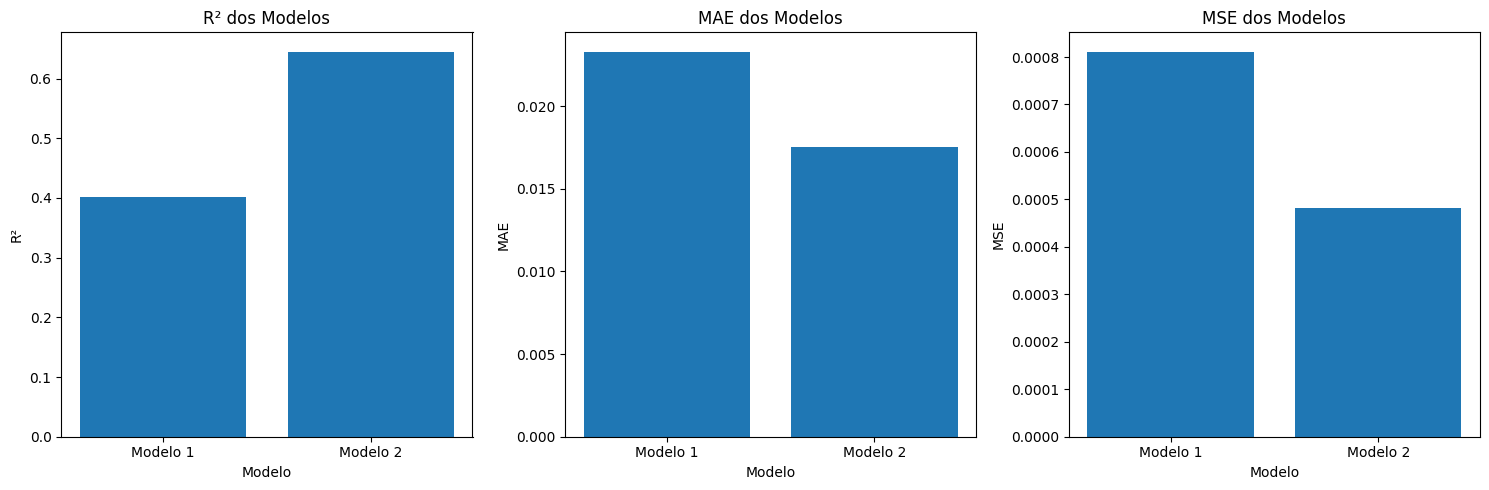

In [33]:
# Crie os gráficos comparativos das métricas
plt.figure(figsize=(15, 5))

# Gráfico 1: R²
plt.subplot(1, 3, 1)
plt.bar(comparacao_modelos['Modelo'], comparacao_modelos['R²'])
plt.title('R² dos Modelos')
plt.xlabel('Modelo')
plt.ylabel('R²')

#MAE
plt.subplot(1, 3, 2)
plt.bar(comparacao_modelos['Modelo'], comparacao_modelos['MAE'])
plt.title('MAE dos Modelos')
plt.xlabel('Modelo')
plt.ylabel('MAE')

#MSE
plt.subplot(1, 3, 3)
plt.bar(comparacao_modelos['Modelo'], comparacao_modelos['MSE'])
plt.title('MSE dos Modelos')
plt.xlabel('Modelo')
plt.ylabel('MSE')

plt.tight_layout()
plt.show()

## Análise comparativa final

Responda com base na tabela e nos gráficos comparativos.

**1. Qual modelo apresentou o maior R²? Informe os valores dos dois modelos.**  
Resposta:  O Modelo 2 apresentou o maior R², com 0,6452, enquanto o Modelo 1 apresentou 0,4018. Isso indica maior capacidade de explicar os dados.


**2. Qual modelo apresentou o menor MAE? Informe os valores dos dois modelos.**  
Resposta:  O Modelo 2 apresentou o menor MAE, com 0,0176, contra 0,0233 do Modelo 1, indicando menor erro médio.


**3. Qual modelo apresentou o menor MSE? Informe os valores dos dois modelos.**  
Resposta:  O Modelo 2 apresentou o menor MSE, com 0,0005, enquanto o Modelo 1 teve 0,0008.


**4. As três métricas indicaram o mesmo modelo como o de melhor desempenho? Justifique comparando os resultados.**  
Resposta: Sim. As três métricas indicaram melhor desempenho do Modelo 2, pois ele teve maior R² e menores valores de MAE e MSE.


**5. O que mudou no desempenho quando as cinco variáveis de maior correlação foram substituídas pelo conjunto completo de variáveis `tau` e `g`?**  
Resposta: Ao utilizar todas as variáveis tau e g, o desempenho melhorou. O R² aumentou e os valores de MAE e MSE diminuíram.


**6. Considerando os resultados obtidos, qual modelo você escolheria para prever `stab`? Justifique com R², MAE e MSE.**  
Resposta: Eu escolheria o Modelo 2 para prever stab, pois apresentou R² maior e erros MAE e MSE menores, demonstrando melhor desempenho nos dados de teste.

# Conferência e entrega

Antes de entregar, verifique se o notebook contém:

- identificação dos integrantes;
- carregamento e análise inicial do dataset;
- `y` definido com a coluna `stab`;
- matriz de correlação e mapa de calor;
- seleção das cinco maiores correlações absolutas;
- cinco gráficos de dispersão em relação a `stab`;
- Modelo 1 com as cinco variáveis selecionadas;
- Modelo 2 com todas as variáveis `tau` e `g`;
- R², MAE e MSE dos dois modelos;
- tabela e gráficos comparativos das métricas;
- respostas da análise comparativa final;
- todas as células executadas e sem erros.

Salve o arquivo `.ipynb` e faça o upload no **repositório GitHub da atividade criado anteriormente**. Este notebook fará parte do **Checkpoint 2**.